<a href="https://colab.research.google.com/github/a2w3r4/Binary-Image-Classification-on-Fashion-MNIST-with-Tensorflow-Quantum-and-Cirq/blob/main/Binary_Image_Classification_on_Fashion_MNIST_with_Tensorflow_Quantum_and_cirq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
from IPython.display import clear_output
!pip install -q tensorflow==2.8.0
clear_output()

In [85]:
!pip install -q tensorflow_quantum==0.7.6

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cirq-aqt 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.5.0 which is incompatible.
cirq-web 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.5.0 which is incompatible.
cirq-ionq 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.5.0 which is incompatible.
cirq 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.5.0 which is incompatible.
cirq 1.6.1 requires cirq-google==1.6.1, but you have cirq-google 1.5.0 which is incompatible.
cirq-pasqal 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.5.0 which is incompatible.


In [ ]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 29.3 MB/s eta 0:00:00
  Attempting uninstall: cirq-core
    Found existing installation: cirq-core 1.5.0
    Uninstalling cirq-core-1.5.0:
      Successfully uninstalled cirq-core-1.5.0
  Attempting uninstall: cirq-google
    Found existing installation: cirq-google 1.5.0
    Uninstalling cirq-google-1.5.0:
      Successfully uninstalled cirq-google-1.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-quantum 0.7.6 requires cirq-core==1.5.0, but you have cirq-core 1.6.1 which is incompatible.
tensorflow-quantum 0.7.6 requires cirq-google==1.5.0, but you have c

# Import the dataset and required packages

In [ ]:
import tensorflow as tf

#Data Processing Tools
import numpy as np
from sklearn.model_selection import train_test_split

#QML Tools
import tensorflow_quantum as tfq
import cirq
import sympy

#Visualization Tools
from cirq.contrib.svg import SVGCircuit
import matplotlib.pyplot as plt

In [ ]:
print("We are using Tensorflow Quantum Version {}".format(tfq.__version__))
print("We are using Cirq Version {}".format(cirq.__version__))

We are using Tensorflow Quantum Version 0.7.6
We are using Cirq Version 1.6.1


Import Dataset

In [ ]:
from tensorflow.keras.datasets import fashion_mnist as dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = dataset.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("The Shape of x_train is {}".format(x_train.shape))
print("The Shape of y_train is {}".format(y_train.shape))
print("The Shape of x_test is {}".format(x_test.shape))
print("The Shape of y_test is {}".format(y_test.shape))

The Shape of x_train is (60000, 28, 28)
The Shape of y_train is (60000,)
The Shape of x_test is (10000, 28, 28)
The Shape of y_test is (10000,)


Here, 60000 is no. of images & 28*28 is pixel value of each image

# 1. Preprocessing the Dataset

In [ ]:
l1 = [3,2,3,4]
for i in l1:
  print((i==3)|(i==2))

True
True
True
False


In [ ]:
def filter_data(x,y):

# filter the data using labels
  keep = (y == 5 ) | ( y == 9 )
  x, y = x[keep], y[keep]

# Convert labels into boolean
# y = True if y == 5
# y = False if y == 9
  y = y == 5
  return x,y

Filter the Train Set

In [ ]:
x_train, y_train = filter_data(x_train, y_train)
x_test, y_test = filter_data(x_test, y_test)

In [ ]:
print("The shape of the x_train is {}".format( x_train.shape))
print("The shape of the y_train is {}".format( y_train.shape))
print("The shape of the x_test is {}".format( x_test.shape))
print("The shape of the y_test is {}".format( y_test.shape))

The shape of the x_train is (12000, 28, 28)
The shape of the y_train is (12000,)
The shape of the x_test is (2000, 28, 28)
The shape of the y_test is (2000,)


In [ ]:
# Let's have a look at the first image from our x_train and the corresponding label from y_train

The First Image has the label False


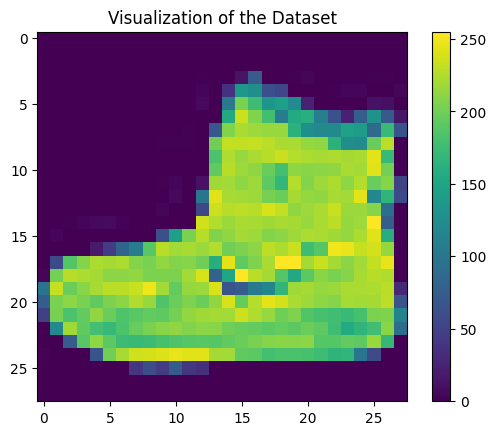

In [ ]:
print("The First Image has the label {}".format(y_train[0]))
plt.imshow(x_train[0])
plt.colorbar()
plt.title('Visualization of the Dataset')
plt.show()

From the colorbar in the above visualization, it is clear that we've grayscle images in the dataset and hence their values range from 0 to 255.
However we would like to scale these pixel values in our dataset so that the values range from 0 to 1. This will help us to converge our CNN training faster

# `Normalize the test and train image data`

In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0

The First Image has the label False


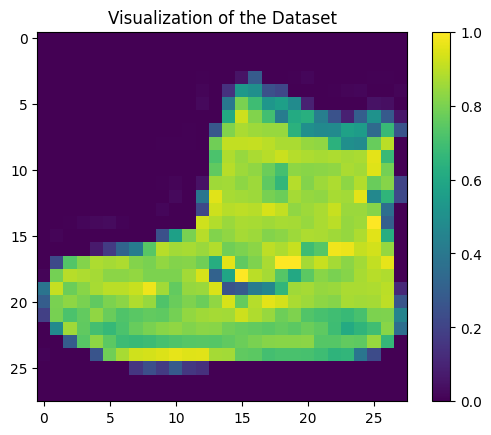

In [ ]:
print("The First Image has the label {}".format(y_train[0]))
plt.imshow(x_train[0])
plt.colorbar()
plt.title('Visualization of the Dataset')
plt.show()

Reshape our image

In [ ]:
x_train = x_train.reshape(x_train.shape[0], *(28, 28, 1))
x_test = x_test.reshape(x_test.shape[0], *(28, 28, 1))

28*28 is pixel size and 1 is channel

Downscaling the images

In [ ]:
x_train = tf.image.resize(x_train, (2,2)).numpy()
x_test = tf.image.resize(x_test, (2,2)).numpy()

We downscale the image from 28*28 into 2*2. So, it's easy to work with quantum part and also convert it into numpy array

Let's look at the first image from our resized x_train

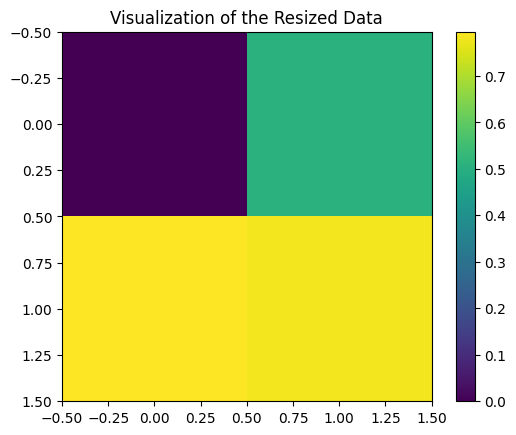

In [ ]:
plt.imshow(x_train[0,:,:,0])
plt.colorbar()
plt.title('Visualization of the Resized Data')
plt.show()

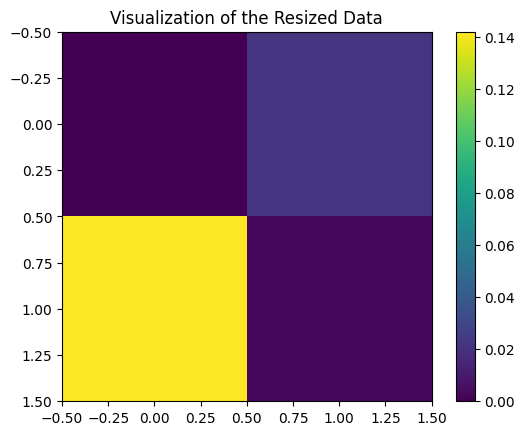

In [ ]:
plt.imshow(x_train[1,:,:,0])
plt.colorbar()
plt.title('Visualization of the Resized Data')
plt.show()

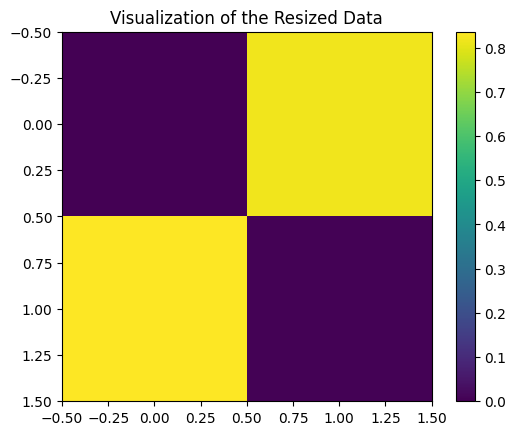

In [ ]:
plt.imshow(x_train[2,:,:,0])
plt.colorbar()
plt.title('Visualization of the Resized Data')
plt.show()

# Train and Validate Dataset

In [ ]:
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size = 0.5, random_state=0)

In [ ]:
print("The shape of the x_train is {}".format(x_train.shape))
print("The shape of the y_train is {}".format(y_train.shape))
print("The shape of the x_valid is {}".format(x_valid.shape))
print("The shape of the y_valid is {}".format(y_valid.shape))

The shape of the x_train is (6000, 2, 2, 1)
The shape of the y_train is (6000,)
The shape of the x_valid is (6000, 2, 2, 1)
The shape of the y_valid is (6000,)


**[Step 1: Processing Pixel Values for Binary Encoding](https://)**

In [ ]:
# Flattening the images
x_train = x_train.reshape(x_train.shape[0], *(1,4,1))
x_valid = x_valid.reshape(x_valid.shape[0], *(1,4,1))
x_test = x_test.reshape(x_test.shape[0], *(1,4,1))

# 2.Data Encoding

Steps involved in Data Encoding
 > Processing pixel values for binary encoding

 > Converting Cirq Circuits to tfq tensors

## ***Processing x_train***

In [ ]:
print(x_train[0])

[[[0.        ]
  [0.00098039]
  [0.83725494]
  [0.8264706 ]]]


We will be using Binary Encoding techniques

In [ ]:
def binary_encode(x, threshold=0.5):
  """
  Encodes the given dataset to use binaary encoding

  Parameters :
  x(array) : Image dtat to be processed for encoding
  threshold(float) : Threshold for binary encoding, 0.5 by default

  Returns :
  encoded_images(array) : Binary encoded Image Data
  """

  encoded_images = list()
  for image in x:
    # pixel value is 1 if it's greater than threshold or else zero
    encoded_image = [1 if j>threshold else 0 for j in image[0]]
    encoded_images.append(encoded_image)
  return encoded_images

In [ ]:
x_train = binary_encode(x_train)

In [ ]:
# Now, Let's have a look on the first example again
print(x_train[0])

[0, 0, 1, 1]


# Quantum Circuit

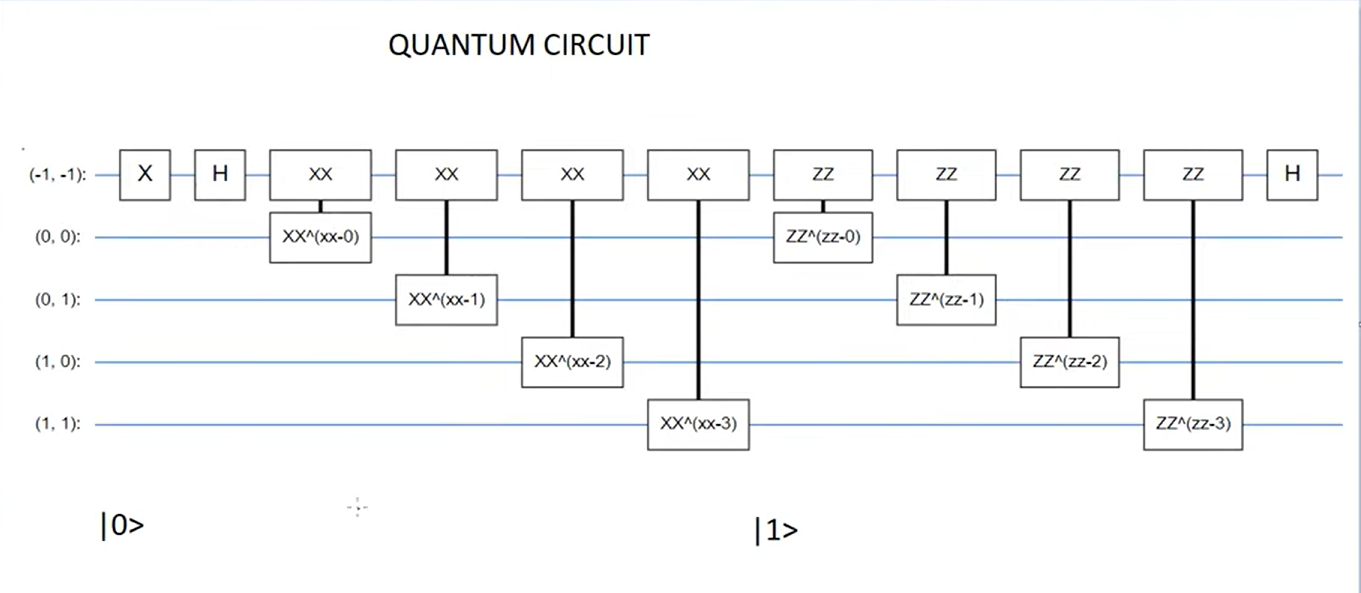

(-1,-1) represents Qubits. (0,0),(0,1),(1,0),(1,1) represents co-ordinates of the qubits. Blocks are Gates

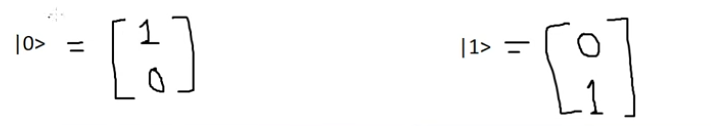

1st is Quantum Zero Gate and 2nd is Quantum One Gate

X Gate -- Pauli-X Gate -> Convert Q zero to Q one & vice-versa.

H Gate -- Hadamard Gate -> Create Superposition.

XX Gate -- Two-Qubit X Interaction -> Creates entanglement b/w two qubits.

ZZ Gate -- Two-Qubit Z Interaction ->
Create Phase Entanglement

All these Gates can be represented by the own simple Matrices.

# Quantum Circuit Construction

In [ ]:
import cirq

In [ ]:
qubit = cirq.NamedQubit("ZeroX")

In [ ]:
circuit = cirq.Circuit(cirq.X(qubit))

In [ ]:
circuit

ZeroX: ───X───

In [ ]:
def create_circuit_from_image(encoded_image):

  qubits = cirq.GridQubit.rect(2,2)
  circuit = cirq.Circuit()
  for i, pixel in enumerate(encoded_image):
    if pixel:
      circuit.append(cirq.X(qubits[i]))
  return circuit

It basically converting [0,0,1,1] into 0 cat, 0 cat, 1 cat, 1 cat gates.

In [ ]:
x_train_circ = [create_circuit_from_image(encoded_image) for encoded_image in x_train]

In [ ]:
print(x_train_circ[0])

(1, 0): ───X───

(1, 1): ───X───


# Converting Cirq Circuits to tfq Tensors

In [ ]:
x_train_tfq = tfq.convert_to_tensor(x_train_circ)

In [ ]:
x_train_tfq[0]

<tf.Tensor: shape=(), dtype=string, numpy=b'\n\x0e\n\x0ctfq_gate_set\x12\x99\x02\x08\x01\x12\x94\x02\n\x87\x01\n\x04\n\x02XP\x12\x16\n\x0econtrol_qubits\x12\x04\n\x02\x1a\x00\x12\x1a\n\x0fexponent_scalar\x12\x07\n\x05\r\x00\x00\x80?\x12\x16\n\x0econtrol_values\x12\x04\n\x02\x1a\x00\x12\x13\n\x08exponent\x12\x07\n\x05\r\x00\x00\x80?\x12\x17\n\x0cglobal_shift\x12\x07\n\x05\r\x00\x00\x00\x00\x1a\x05\x12\x031_0\n\x87\x01\n\x04\n\x02XP\x12\x16\n\x0econtrol_qubits\x12\x04\n\x02\x1a\x00\x12\x1a\n\x0fexponent_scalar\x12\x07\n\x05\r\x00\x00\x80?\x12\x16\n\x0econtrol_values\x12\x04\n\x02\x1a\x00\x12\x13\n\x08exponent\x12\x07\n\x05\r\x00\x00\x80?\x12\x17\n\x0cglobal_shift\x12\x07\n\x05\r\x00\x00\x00\x00\x1a\x05\x12\x031_1'>

# Processing x_valid and x_test

In [ ]:
x_valid = binary_encode(x_valid)
x_test = binary_encode(x_test)

In [ ]:
x_valid = [create_circuit_from_image(encoded_image) for encoded_image in x_valid]
x_test = [create_circuit_from_image(encoded_image) for encoded_image in x_test]

In [ ]:
x_valid_tfq = tfq.convert_to_tensor(x_valid)
x_test_tfq = tfq.convert_to_tensor(x_test)

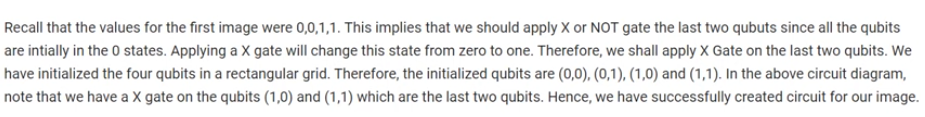

# Quantum Neural Network

Building the Quantum Neural network involves two steps :

1.) Build a class that adds gates layer by layer

2.) Define the QNN using theclass from the above step

In [ ]:
class QNN():
  def __init__(self, data_qubits, readout):
    self.data_qubits = data_qubits
    self.readout = readout

  def add_singleQubit_gate(self, circuit, gate, qubit_index):

    for index in qubit_index:
      circuit.append(gate(self.data_qubits[index]))

  def add_twoQubit_gate(self, circuit, gate, qubit_index):

    if len(qubit_index)!=2:
     raise Exception("The length of the list of indices passes for two qubit \
     gate operations musr be equal to two")
    circuit.append(gate(self.data_qubits[qubit_index[0]], self.data_qubits[qubit_index[1]]))

  def add_layer(self, circuit, gate, symbol_gate):

    for i, qubit in enumerate(self.data_qubits):
      symbol = sympy.Symbol(symbol_gate+ '_' + str(i))
      circuit.append(gate(qubit, self.readout)**symbol)

In [66]:
def create_qnn():

  data_qubits = cirq.GridQubit.rect(2,2)
  readout = cirq.GridQubit(-1, -1)
  circuit = cirq.Circuit()

  # Prepare the readout qubit.
  circuit.append(cirq.X(readout))
  circuit.append(cirq.H(readout))

  qnn = QNN(
      data_qubits = data_qubits,
      readout=readout)

  # Add the ising coupling XX gate
  qnn.add_layer(circuit, cirq.XX, "XX")
  qnn.add_layer(circuit, cirq.ZZ, "zz")

  # Finally, prepare the readout qubit.
  circuit.append(cirq.H(readout))

  return circuit, cirq.Z(readout)







**Matrix representation of XX Gate**

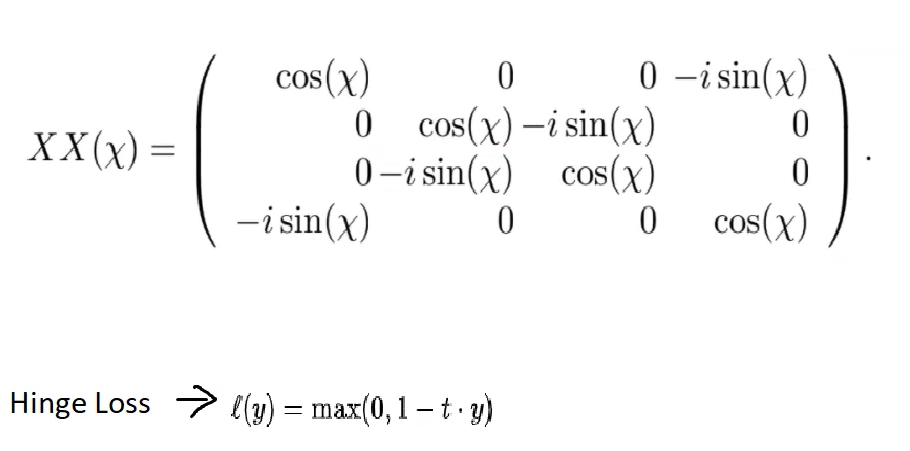

In [67]:
qmodel, model_readout = create_qnn()

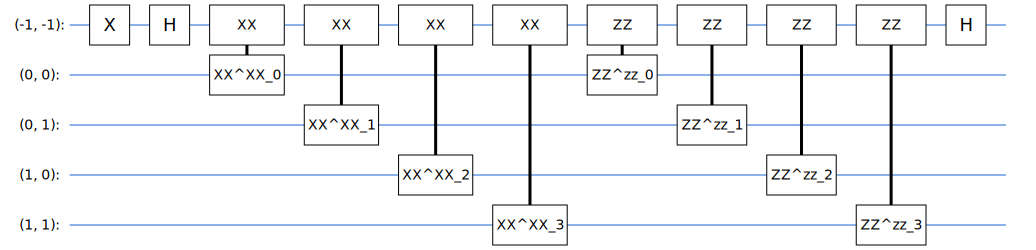

In [68]:
# Let's have a look at our Quantum Circuit that will perform the classification
SVGCircuit(qmodel)

In [5]:
model = tf.keras.Sequential([

    # The input is the data-circuit, encoded as a tf.string
    tf.keras.layers.Input(shape=(), dtype=tf.string),

    # The PQC stands for Parameterized Quantum Circuit
    # This return the expectation value
    tfq.layers.PQC(qmodel, model_readout),
])

NameError: name 'tf' is not defined

In [2]:
# To use Hinge Loss, we convert the labels to 1 and -1
y_train_h = np.array([1 if i==1 else -1 for i in y_train])
y_valid_h = np.array([1 if i==1 else -1 for i in y_valid])
y_test_h = np.array([1 if i==1 else -1 for i in y_test])

NameError: name 'np' is not defined

In [4]:
# Let's have a look at he first label feom the training dataset
print(y_train_h[0])

NameError: name 'y_train_h' is not defined